# 3 Dataset de emisión de co2 en diferentes modelos de autos.
* Este dataset se extrajo desde: 
- **https://www.kaggle.com/datasets/brsahan/vehicle-co2-emissions-dataset**

In [1]:
import os
import sys

carpeta_actual = os.getcwd()
ruta_raiz = os.path.dirname(carpeta_actual)
print(ruta_raiz)
# Añade la raíz al buscador de Python si no está ahí
if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

# Ahora ya puedes importar tus funciones
from utilidades.mis_funciones import *

c:\Users\mbang\Desktop\GitMikis\Proyecto2


In [5]:
# Cargar el archivo
ruta_archivo = f"{ruta_raiz}/datasets/co2.csv"
df3 = cargar_archivo_drive(ruta_archivo)
analisis_inicial(df3)

Tamaño: (7385, 12)

Primeras 5 filas del DataFrame:
    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7      

### Este dataset de emisiones de CO2 tiene hartos duplicados. Es importante quitarlos para que el análisis sea fidedigno.

In [6]:
# Como siempre, primero la copia. (Juan Segura vivió muchos años)
df3_clean = df3.copy()
df3_clean.shape

(7385, 12)

In [7]:
# Limpiando duplicados
print(f"Filas antes de eliminar duplicados: {df3_clean.shape[0]}")
df3_clean.drop_duplicates(inplace=True)
print(f"Filas después de eliminar duplicados: {df3_clean.shape[0]}")

display(df3_clean.head())

Filas antes de eliminar duplicados: 7385
Filas después de eliminar duplicados: 6282


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


### Ahora que el dataset de CO2 está sin duplicados, voy a ver cómo se distribuyen sus variables numéricas con los histogramas y así  entender si los datos se agrupan, si son simétricos o si tienen algún sesgo.

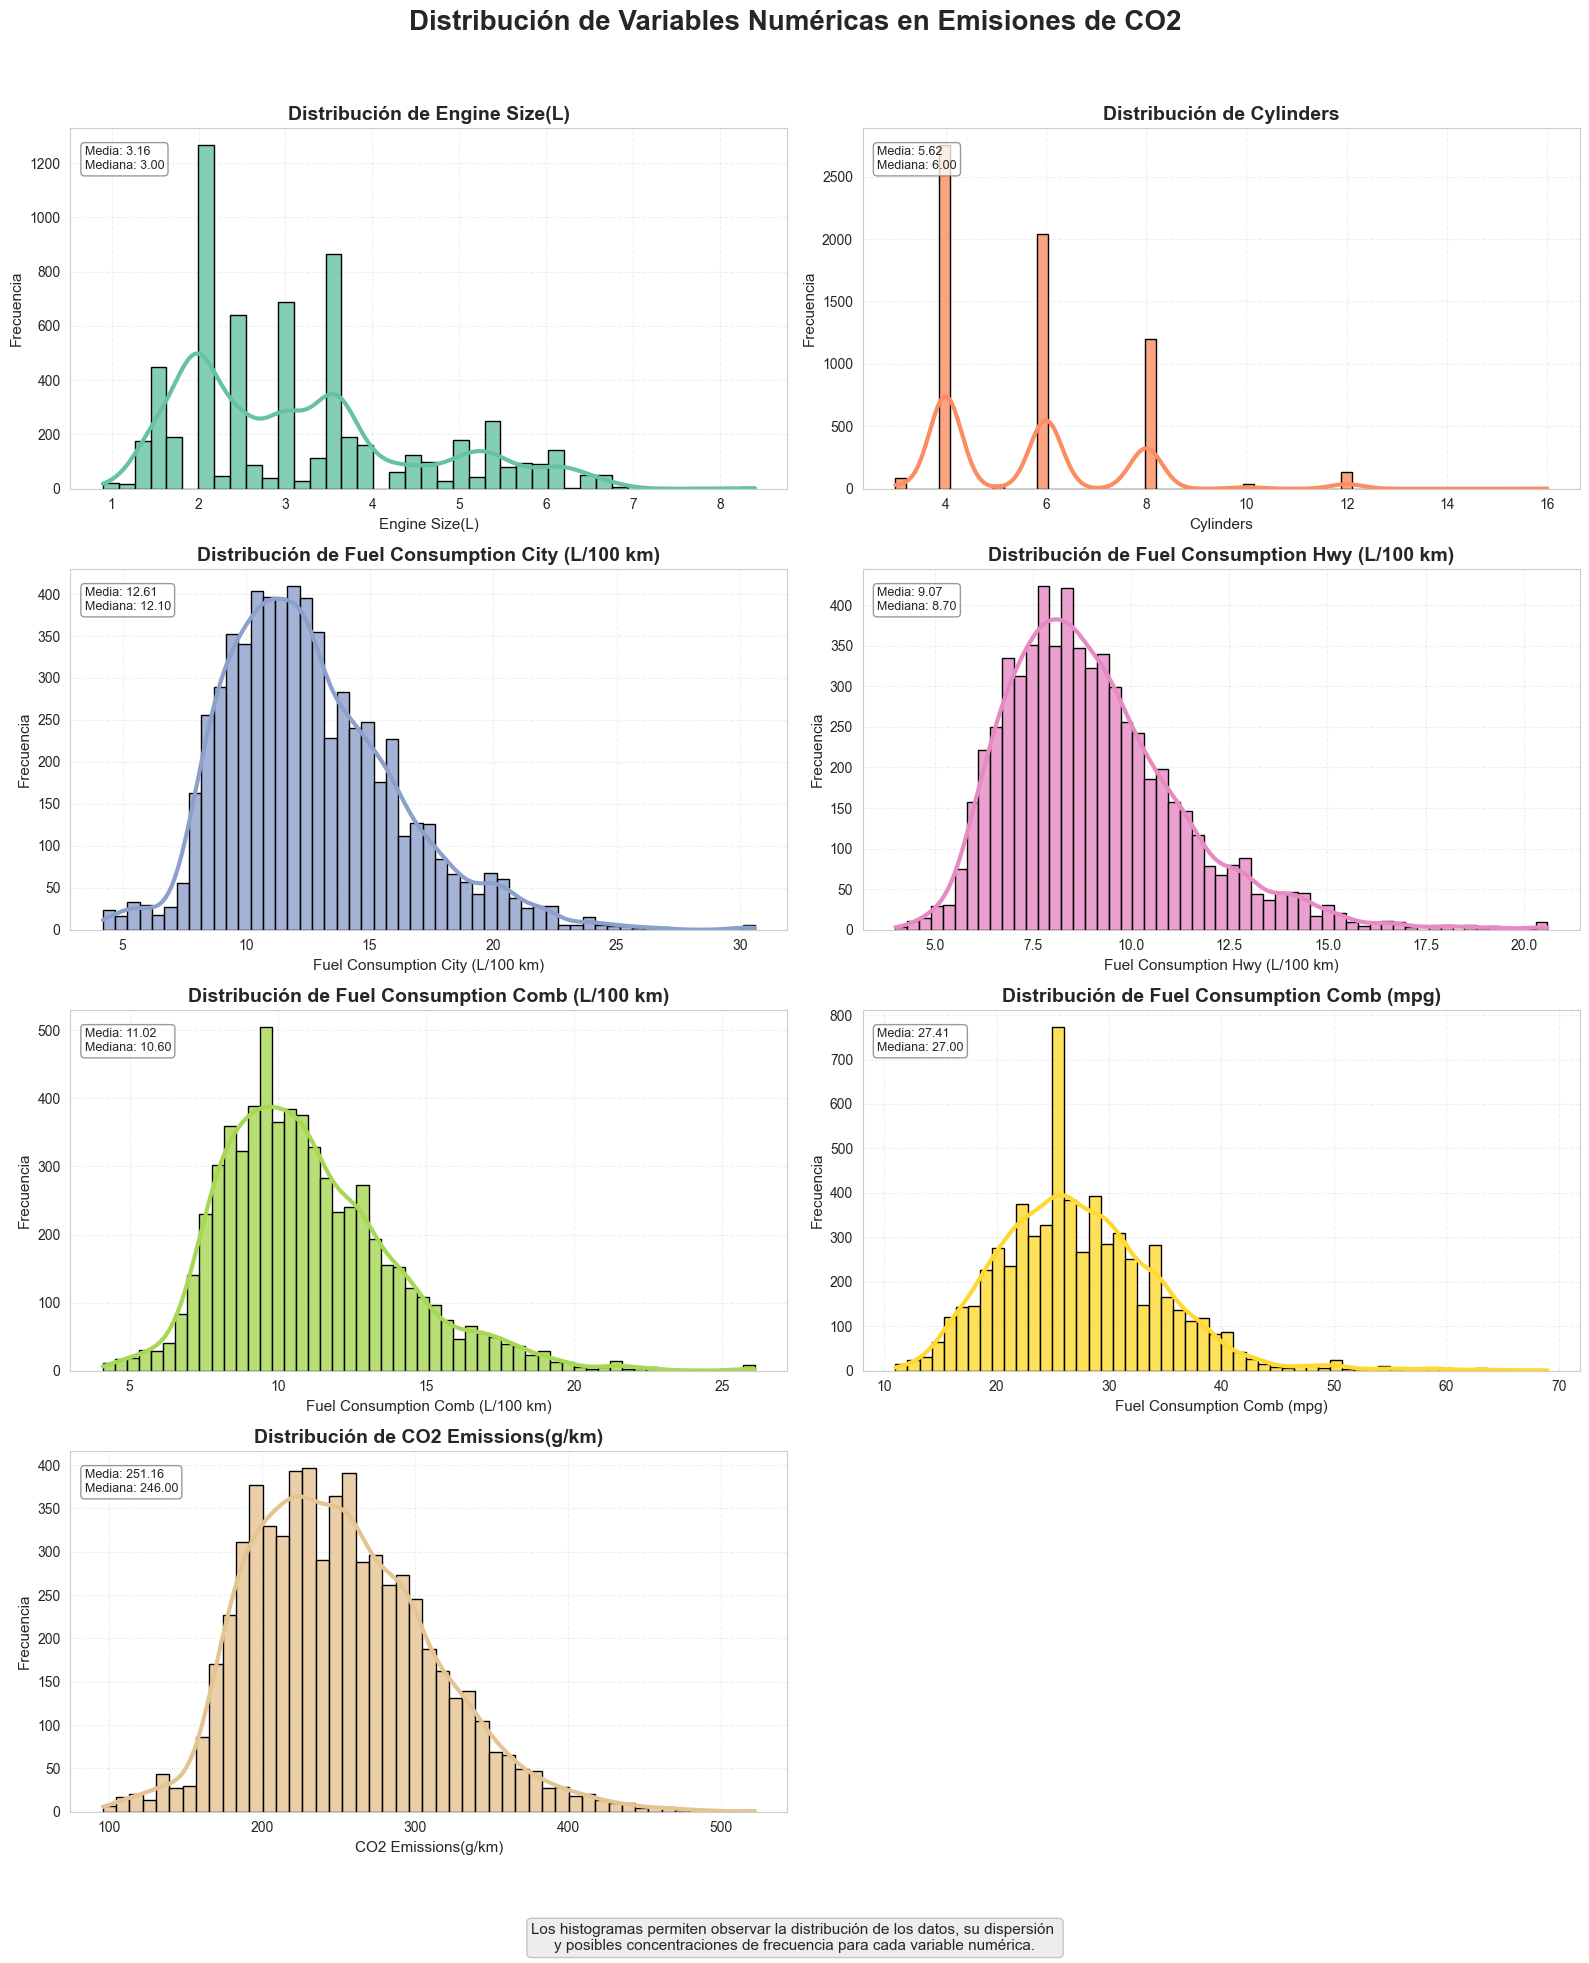

In [8]:
# Voy a seleccionar todas las columnas numéricas para los histogramas
num_cols_df3 = df3_clean.select_dtypes(include=[np.number]).columns

# Usar la función graficar_histogramas
graficar_histogramas(df3_clean, titulo='Distribución de Variables Numéricas en Emisiones de CO2')

### Es el turno de los outliers, voy a identificar esos valores extremos y así entender si son datos anómalos o si representan modelos de autos muy específicos o poco comunes.

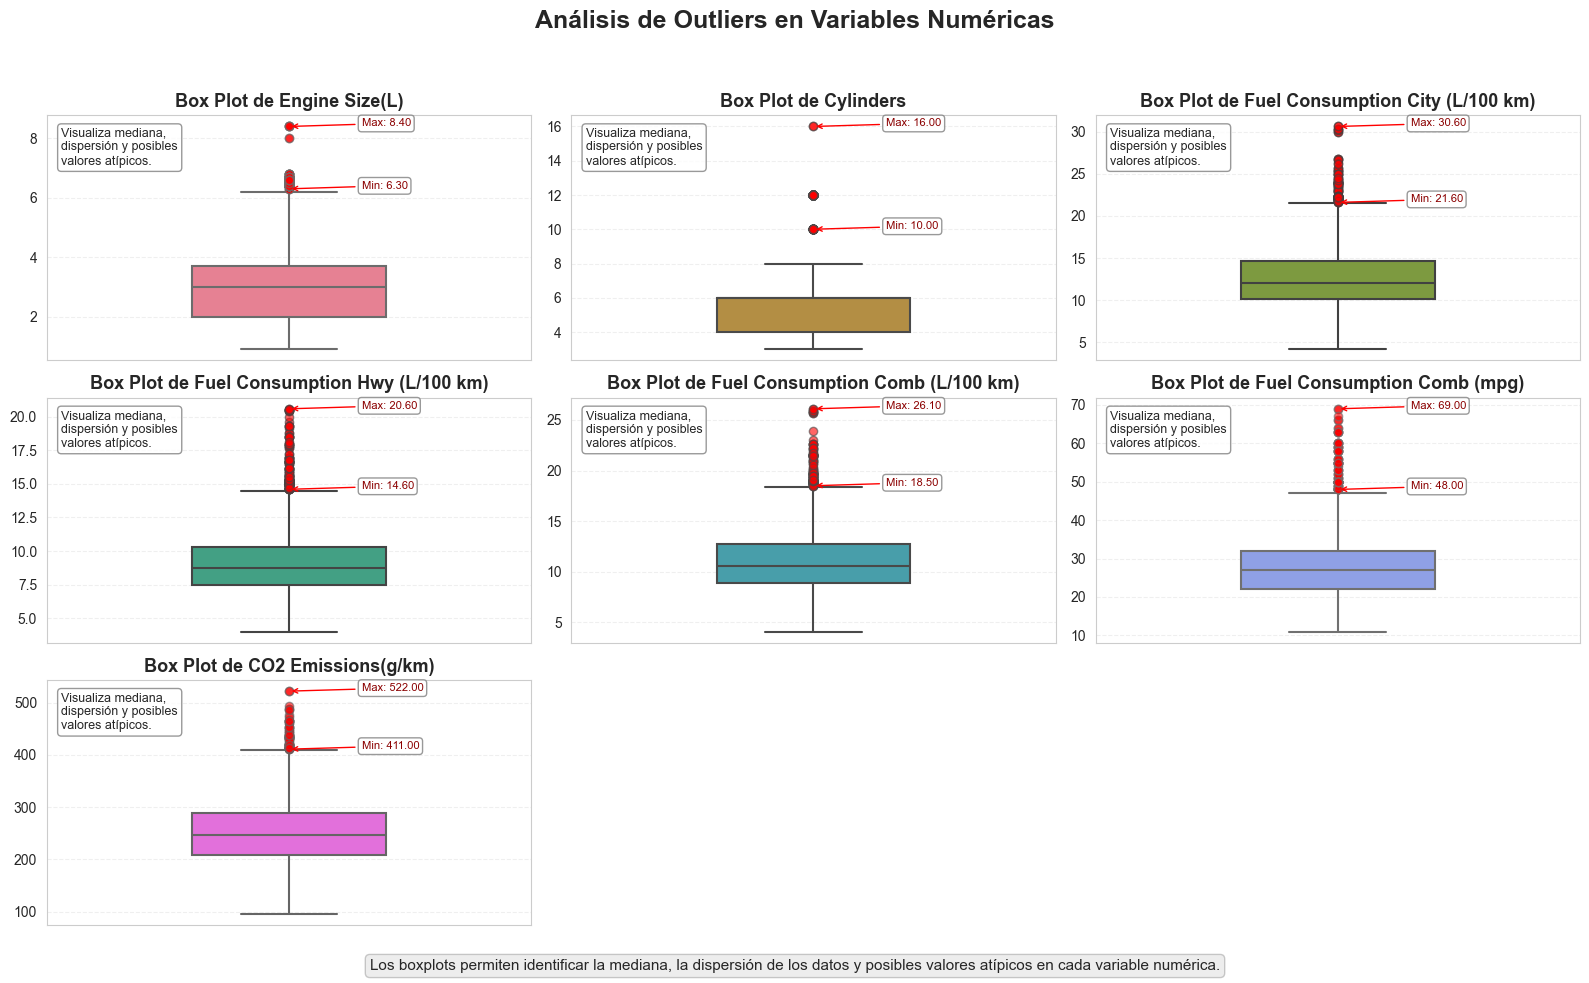

In [9]:
# Identificar columnas numéricas para el análisis de outliers
col_num_df3 = num_cols_df3.tolist()

# Usar la función boxplots para visualizar los outliers
boxplots(df3_clean, col_num_df3)

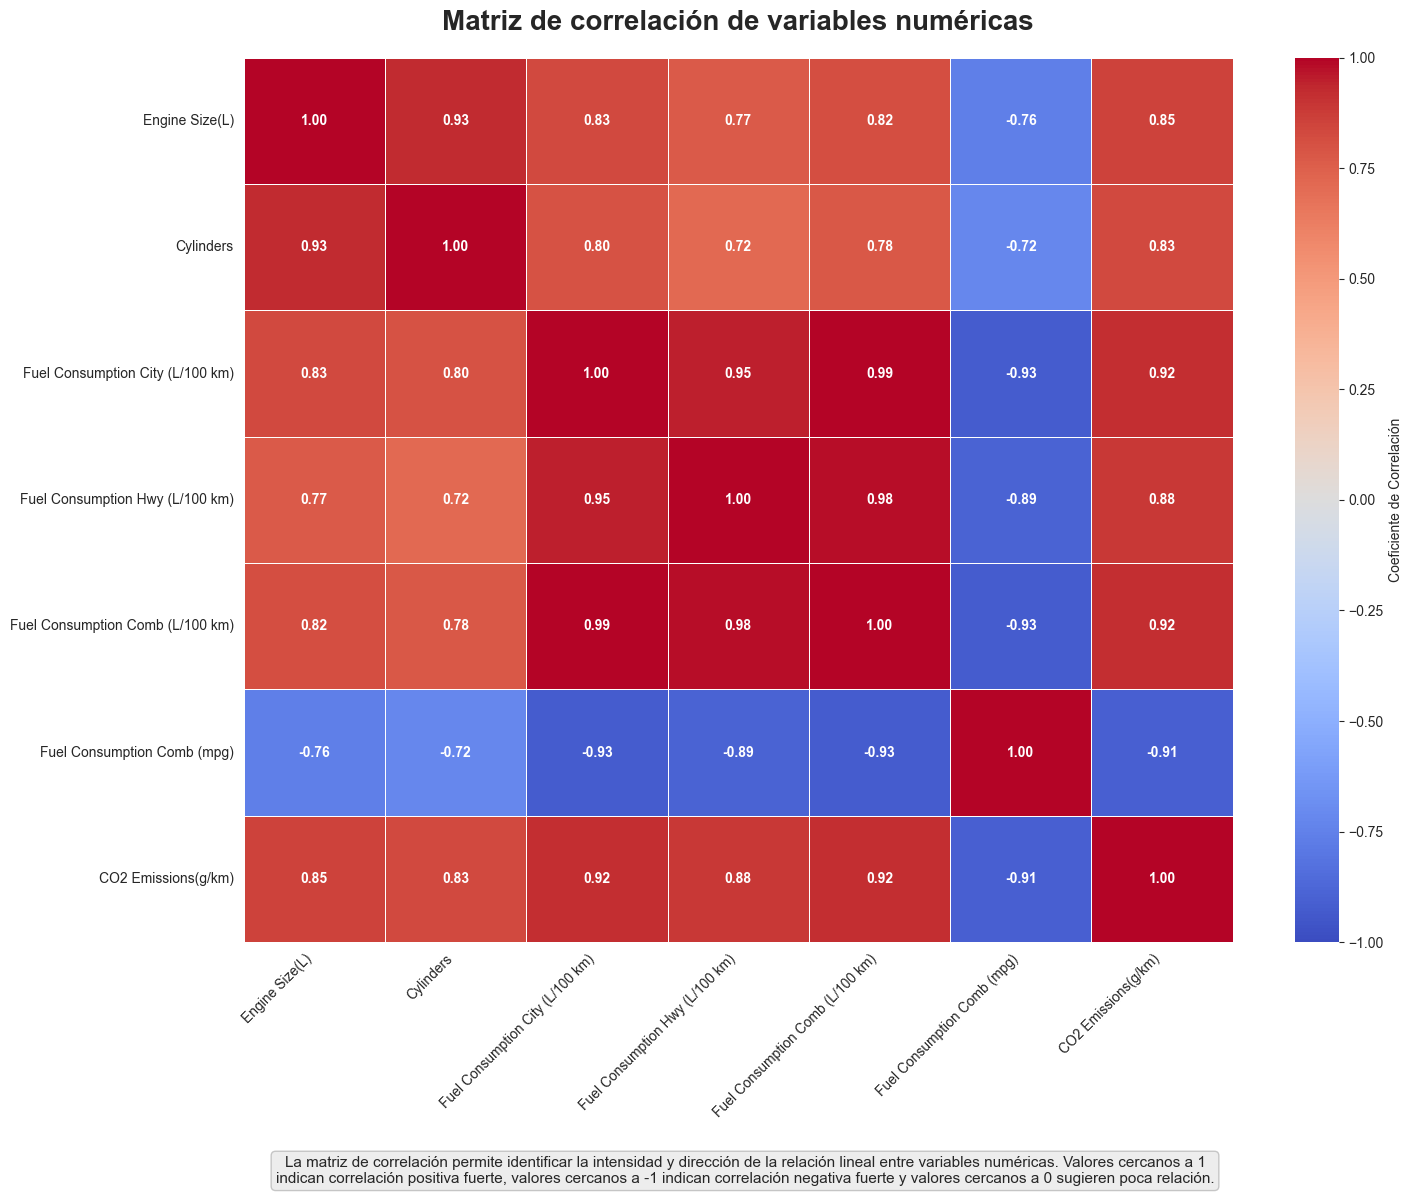

In [10]:
# Ahora veré la matriz de correlación
# Excluyo 'Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type' ya que son categóricas
col_num_df3_corr = df3_clean.select_dtypes(include=[np.number]).columns

# Ahora llamo a mi funcion de correlación
matriz_corr(df3_clean, num_cols_df3)

### Resumen del EDA para DataFrame Emisiones de CO2

#### Observaciones generales:

* Se comenzó con 7385 registros y 12 columnas. Después de la limpieza, quedó con 6284 registros, lo que significa que se eliminaron 1101 filas duplicadas.
* Este dataset venía de lujo, sin valores nulos en ninguna de sus columnas. Eso me ahorra tiempo, muuucho tiempo en la limpieza.
* La mayoría de las columnas numéricas están bien (float64, int64), y las categóricas (object) también. No fue necesario hacer conversiones complicadas.

#### Análisis de distribuciones:

* **Engine Size(L) y Cylinders:** Estas variables muestran distribuciones con sesgos hacia la derecha, lo que indica que gran parte de los vehículos tienen motores de tamaño pequeño o mediano y menos cilindros, con algunos modelos de mayor potencia siendo menos frecuentes.
* **Fuel Consumption:** Las distribuciones de consumo de combustible también son asimétricas a la derecha. La mayoría de los autos tienen consumos moderados, y hay una cola de vehículos con alto consumo. Se puede ver una correlación positiva fuerte entre las tres variables de consumo.
* **CO2 Emissions(g/km):** Esta es nuestra variable objetivo, y también muestra una distribución asimétrica a la derecha, lo que sugiere que la mayoría de los vehículos emiten cantidades moderadas de CO2, con algunos contaminantes más grandes en la cola derecha de la distribución.

#### Outliers:

* Los boxplots mostraron que casi todas las variables numéricas tienen outliers. Esto es bastante normal debido a la naturaleza varieda de modelos, desde autos pequeños y eficientes hasta SUVs grandes o deportivos de alto rendimiento.
* La mayoría de estos outliers no son errores de datos, sino valores legítimos que reflejan la diversidad del parque automotriz.
* Si el objetivo es predecir las emisiones de CO2, estos valores extremos serán importantes para que el modelo aprenda a identificar las características de los vehículos que más contaminan.

#### Análisis de la matriz de correlación

##### Correlaciones clave con CO2 Emissions(g/km):
* Se observa una correlación positiva extremadamente alta entre CO2 Emissions(g/km) y las variables de consumo de combustible: Fuel Consumption City (L/100 km), Fuel Consumption Hwy (L/100 km), y especialmente Fuel Consumption Comb (L/100 km). Esto es completamente lógico: a mayor consumo de combustible, mayores emisiones de CO2.
* Engine Size(L) y Cylinders también muestran correlaciones positivas fuertes con CO2 Emissions(g/km). Esto significa que vehículos con motores más grandes y más cilindros tienden a tener mayores emisiones. ¡Más potencia, más CO2!
* Fuel Consumption Comb (mpg) tiene una correlación negativa fuerte con CO2 Emissions(g/km). Esto es esperable, ya que un mayor rendimiento de combustible se traduce en menores emisiones de CO2.


#### El problema más evidente es predecir las emisiones de CO2 basándose en las características del vehículo. Esto permitiría entender qué factores influyen más en la contaminación. También se podrían crear nuevas características, como la relación entre el tamaño del motor y el consumo, o categorizar variables como el tipo de transmisión, para mejorar la capacidad predictiva del modelo.
#### Se podría investigar qué tipo de vehículos tienen las emisiones de CO2 más altas, lo que podría ser relevante para políticas medioambientales.